# Flexible body with the floating frame of reference formulation

Notebook `python/Notebooks/tutorialFFRF.ipynb`.

A flexible pendulum with the floating frame of reference formulation (FFRF): Netgen meshes it and NGsolve computes the
finite element matrices, the body is reduced to Hurty-Craig-Bampton modes, and it hangs on a revolute joint. It needs
the package ngsolve (`pip install ngsolve`). The outputs below each cell are those of the last run.

In [1]:
import exudyn as exu
from exudyn.utilities import *  # includes itemInterface and rigidBodyUtilities
import exudyn.graphics as graphics
from exudyn.FEM import *
from exudyn.interactive import ShowImage
import numpy as np
import time
import ngsolve as ngs
from netgen.csg import CSGeometry, OrthoBrick, Pnt

SC = exu.SystemContainer()
mbs = SC.AddSystem()

The parameters, and the mesh of a simple brick made with Netgen's CSG geometry - a brick makes the boundary interfaces
and the joint simple. In Jupyter, `webgui_jupyter_widgets` shows the mesh, see the Netgen documentation.

In [2]:
a = 0.025   # height/width of beam
b = a
h = 0.5 * a # mesh size
L = 1       # length of beam
nModes = 8

rho = 1000
Emodulus = 1e8
nu = 0.3
meshOrder = 1  # use order 2 for higher accuracy, but more unknowns

geo = CSGeometry()
geo.Add(OrthoBrick(Pnt(0, -a, -b), Pnt(L, a, b)))
mesh = ngs.Mesh(geo.GenerateMesh(maxh=h))
mesh.Curve(1)

The `FEMinterface` imports the mesh from NGsolve, with the mechanical properties of the material, and holds the finite
element data:

In [3]:
fem = FEMinterface()
[bfM, bfK, fes] = fem.ImportMeshFromNGsolve(mesh, density=rho, youngsModulus=Emodulus,
                                            poissonsRatio=nu, meshOrder=meshOrder)
print("nNodes=", fem.NumberOfNodes())

nNodes= 2435


The eigenmodes of the free body do not respect the boundary conditions and would be inaccurate, so we use
Hurty-Craig-Bampton modes. They need the boundary interfaces as lists of node numbers and weights; the `FEMinterface`
finds the nodes on planar or cylindrical surfaces. The first boundary's modes are eliminated, as they are fixed to the
reference frame of the FFRF object.

In [4]:
pLeft = [0, -a, -b]
pRight = [L, -a, -b]
nTip = fem.GetNodeAtPoint(pRight) #for the sensor
nodesLeftPlane = fem.GetNodesInPlane(pLeft, [-1, 0, 0])
weightsLeftPlane = fem.GetNodeWeightsFromSurfaceAreas(nodesLeftPlane)

start_time = time.time()
fem.ComputeHurtyCraigBamptonModes(boundaryNodesList=[nodesLeftPlane], nEigenModes=nModes,
                                  useSparseSolver=True, computationMode=HCBstaticModeSelection.RBE2)
print("HCB modes needed %.3f seconds" % (time.time() - start_time))

HCB modes needed 0.108 seconds


Stress modes for the postprocessing - not needed for the simulation, but they show the stresses:

In [5]:
mat = KirchhoffMaterial(Emodulus, nu, rho)
varType = exu.OutputVariableType.StressLocal
fem.ComputePostProcessingModesNGsolve(fes, material=mat, outputVariableType=varType)
SC.visualizationSettings.contour.reduceRange = False
SC.visualizationSettings.contour.outputVariable = varType
SC.visualizationSettings.contour.outputVariableComponent = 0  # x-component

The FFRF object made from the modes, added to `mbs`, with gravity:

In [6]:
cms = ObjectFFRFreducedOrderInterface(fem)
objFFRF = cms.AddObjectFFRFreducedOrder(mbs, positionRef=[0, 0, 0], initialVelocity=[0, 0, 0],
                                        initialAngularVelocity=[0, 0, 0], gravity=[0, -9.81, 0],
                                        color=[0.1, 0.9, 0.1, 1.])

A revolute joint at the left end: a `MarkerSuperElementRigid` on the nodes of the left face, with their weights -
they give the average (midpoint) position of the non-uniform surface mesh accurately -, and a generic joint to the
ground with the rotation about $z$ free:

In [7]:
oGround = mbs.CreateGround(referencePosition=[0, 0, 0])
mGround = mbs.AddMarker(MarkerBodyRigid(bodyNumber=oGround, localPosition=[0, 0, 0]))
mLeft = mbs.AddMarker(MarkerSuperElementRigid(bodyNumber=objFFRF['oFFRFreducedOrder'],
                                              meshNodeNumbers=np.array(nodesLeftPlane),
                                              weightingFactors=weightsLeftPlane))
oJoint = mbs.AddObject(GenericJoint(markerNumbers=[mGround, mLeft], constrainedAxes=[1, 1, 1, 1, 1, 0],
                                    visualization=VGenericJoint(axesRadius=0.1 * a, axesLength=0.1 * a)))

A sensor of the displacement of the tip node, and assemble:

In [8]:
sensTipDispl = mbs.AddSensor(SensorSuperElement(bodyNumber=objFFRF['oFFRFreducedOrder'], meshNodeNumber=nTip,
                                                storeInternal=True,
                                                outputVariableType=exu.OutputVariableType.Displacement))
mbs.Assemble()

The simulation settings, some visualization settings, and four seconds of the swinging pendulum:

In [9]:
simulationSettings = exu.SimulationSettings()
SC.visualizationSettings.nodes.show = False
SC.visualizationSettings.markers.show = False
SC.visualizationSettings.loads.show = False
SC.visualizationSettings.general.showSolverInformation = False

h = 1e-3
tEnd = 4
simulationSettings.timeIntegration.numberOfSteps = int(tEnd / h)
simulationSettings.timeIntegration.endTime = tEnd
simulationSettings.timeIntegration.newton.useModifiedNewton = True
simulationSettings.solution.sensors.writePeriod = h
simulationSettings.timeIntegration.generalizedAlpha.spectralRadius = 0.8

mbs.SolveDynamic(simulationSettings=simulationSettings)

uTip = mbs.GetSensorValues(sensTipDispl)
print("nModes=", nModes, ", tip displacement=", uTip)

nModes= 8 , tip displacement= [-1.02332099e-02 -1.21177798e-01 -3.89491831e-06]


The pendulum at the end, with the stresses $\sigma_{xx}$:

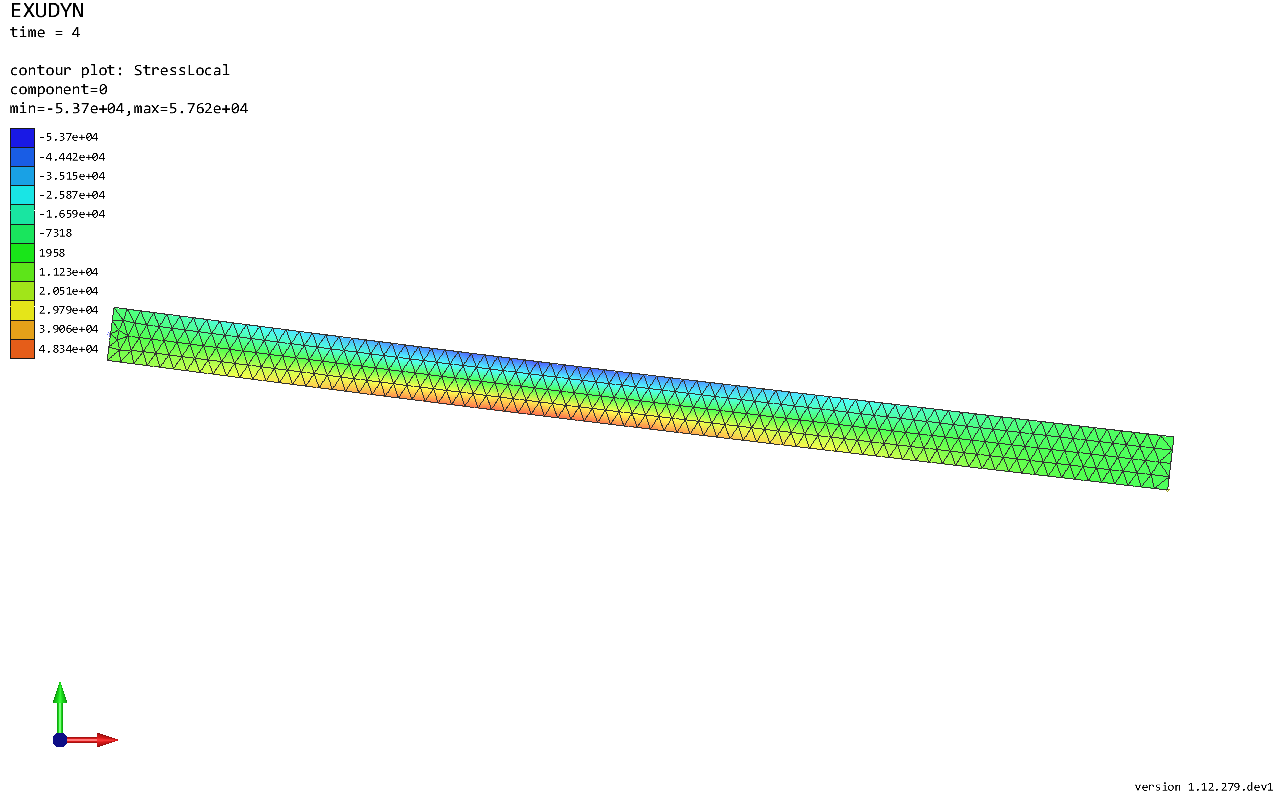

In [10]:
image = ShowImage(SC, size=[1280,800])

The tip displacement over time:

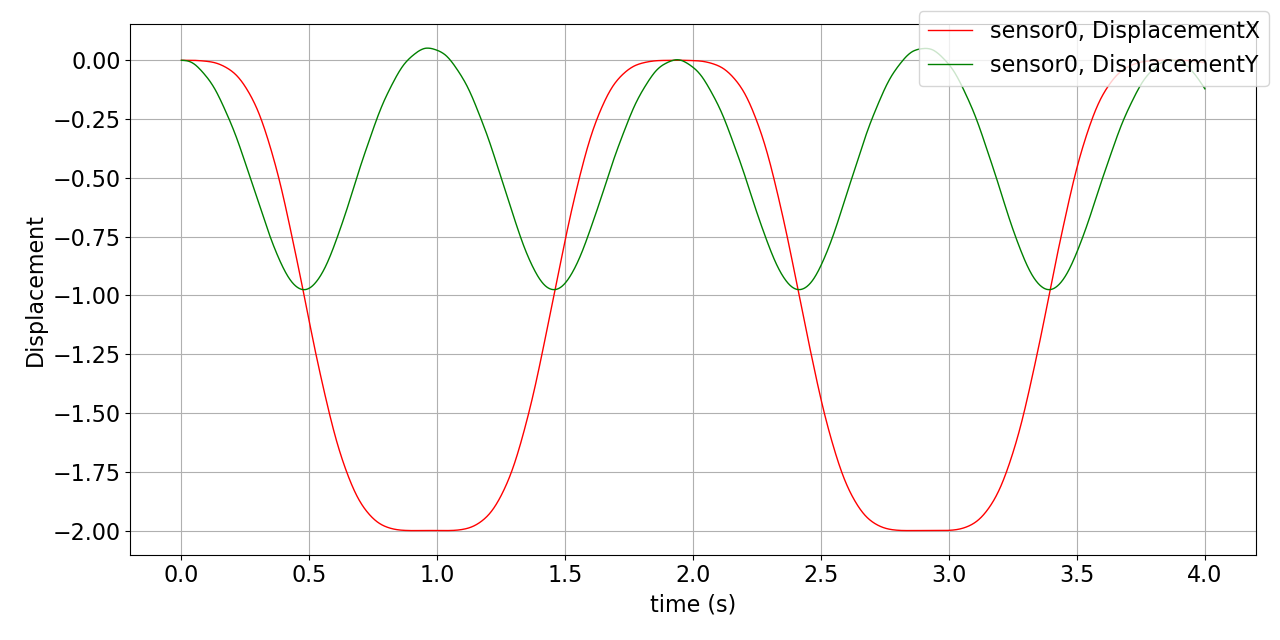

In [11]:
mbs.PlotSensor(sensTipDispl, components=[0,1], closeAll=True)

In a script, `mbs.SolutionViewer()` shows the swinging pendulum with its stresses.